# TorchInfo

In [ ]:
pip install torchinfo

In [ ]:
!git clone https://github.com/DepthAnything/Depth-Anything-V2
%cd Depth-Anything-V2
!pip install -r requirements.txt

Cloning into 'Depth-Anything-V2'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 136 (delta 41), reused 34 (delta 34), pack-reused 65 (from 1)
Receiving objects: 100% (136/136), 45.17 MiB | 28.78 MiB/s, done.
Resolving deltas: 100% (44/44), done.
/content/Depth-Anything-V2/Depth-Anything-V2


In [ ]:
!git clone https://huggingface.co/spaces/depth-anything/Depth-Anything-V2 Depth-Anything-V2-H
%cd Depth-Anything-V2
!pip install -r requirements.txt

Cloning into 'Depth-Anything-V2-H'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 154 (delta 46), reused 0 (delta 0), pack-reused 4 (from 1)
Receiving objects: 100% (154/154), 7.75 MiB | 16.47 MiB/s, done.
Resolving deltas: 100% (46/46), done.
[Errno 2] No such file or directory: 'Depth-Anything-V2'
/content/Depth-Anything-V2/Depth-Anything-V2


In [ ]:
!wget -P /content https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth?download=true
!mv "/content/depth_anything_v2_vitl.pth?download=true" "/content/depth_anything_v2_vitl.pth"

--2024-12-21 02:06:28--  https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth?download=true
Resolving huggingface.co (huggingface.co)... 3.171.171.65, 3.171.171.104, 3.171.171.6, ...
Connecting to huggingface.co (huggingface.co)|3.171.171.65|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/ef/a0/efa040f8dfeabb0d7e03dde47070ea9d72db9ffe066eb5d6a44a7a2803a1477c/a7ea19fa0ed99244e67b624c72b8580b7e9553043245905be58796a608eb9345?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27depth_anything_v2_vitl.pth%3B+filename%3D%22depth_anything_v2_vitl.pth%22%3B&Expires=1735005989&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczNTAwNTk4OX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zL2VmL2EwL2VmYTA0MGY4ZGZlYWJiMGQ3ZTAzZGRlNDcwNzBlYTlkNzJkYjlmZmUwNjZlYjVkNmE0NGE3YTI4MDNhMTQ3N2MvYTdlYTE5ZmEwZWQ5OTI0NGU2N2I2MjRjNzJiODU4

In [ ]:
!mv Depth-Anything-V2 Depth_Anything_V2
!mv Depth-Anything-V2-H Depth_Anything_V2_H

mv: cannot stat 'Depth-Anything-V2': No such file or directory


In [ ]:
import cv2
import torch
import numpy as np
from google.colab.patches import cv2_imshow
from Depth_Anything_V2_H.depth_anything_v2.dpt import DepthAnythingV2

In [ ]:
from torchinfo import summary
import torch

# Define model
model = DepthAnythingV2(encoder='vitl', features=256, out_channels=[256, 512, 1024, 1024])
model.load_state_dict(torch.load('/content/depth_anything_v2_vitl.pth', map_location='cpu'))
model.eval()

# Move the model to a device (CPU for simplicity here)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(DEVICE)

<ipython-input-17-99f476767458>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/depth_anything_v2_vitl.pth', map_location='cpu'))

DepthAnythingV2(
  (pretrained): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-23): 24 x NestedTensorBlock(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (drop): Dropout(p=0.0, inplace=Fal

In [ ]:
def print_model_summary(model, indent=0):
    for name, module in model.named_children():
        print('==' * (indent*indent)  + "> " + f"{name}: {module.__class__.__name__}")
        print_model_summary(module, indent + 1)

print_model_summary(model)


> pretrained: DinoVisionTransformer
==> patch_embed: PatchEmbed
========> proj: Conv2d
========> norm: Identity
==> blocks: ModuleList
========> 0: NestedTensorBlock
==================> norm1: LayerNorm
==================> attn: MemEffAttention
================================> qkv: Linear
================================> attn_drop: Dropout
================================> proj: Linear
================================> proj_drop: Dropout
==================> ls1: LayerScale
==================> drop_path1: Identity
==================> norm2: LayerNorm
==================> mlp: Mlp
================================> fc1: Linear
================================> act: GELU
================================> fc2: Linear
================================> drop: Dropout
==================> ls2: LayerScale
==================> drop_path2: Identity
========> 1: NestedTensorBlock
==================> norm1: LayerNorm
==================> attn: MemEffAttention
================================> qkv: Lin

In [ ]:
from torchinfo import summary

# Provide a dummy input to simulate the input size
dummy_input = (1, 3, 126, 126)  # Batch size 1, 3 color channels, 256x256 image

# Generate the summary
model_summary = summary(model, input_size=dummy_input, col_names=["input_size", "output_size", "num_params", "trainable"])

print(model_summary)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
DepthAnythingV2                                    [1, 3, 126, 126]          [1, 126, 126]             --                        True
├─DinoVisionTransformer: 1-1                       --                        --                        1,404,928                 True
│    └─PatchEmbed: 2-1                             [1, 3, 126, 126]          [1, 81, 1024]             --                        True
│    │    └─Conv2d: 3-1                            [1, 3, 126, 126]          [1, 1024, 9, 9]           603,136                   True
│    │    └─Identity: 3-2                          [1, 81, 1024]             [1, 81, 1024]             --                        --
│    └─ModuleList: 2-2                             --                        --                        --                        True
│    │    └─NestedTensorBlock: 3-3                 [1, 82, 

# Prediction

In [ ]:
raw_img = cv2.imread('/content/5719.jpg')
depth = model.infer_image(raw_img) # HxW raw depth map

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


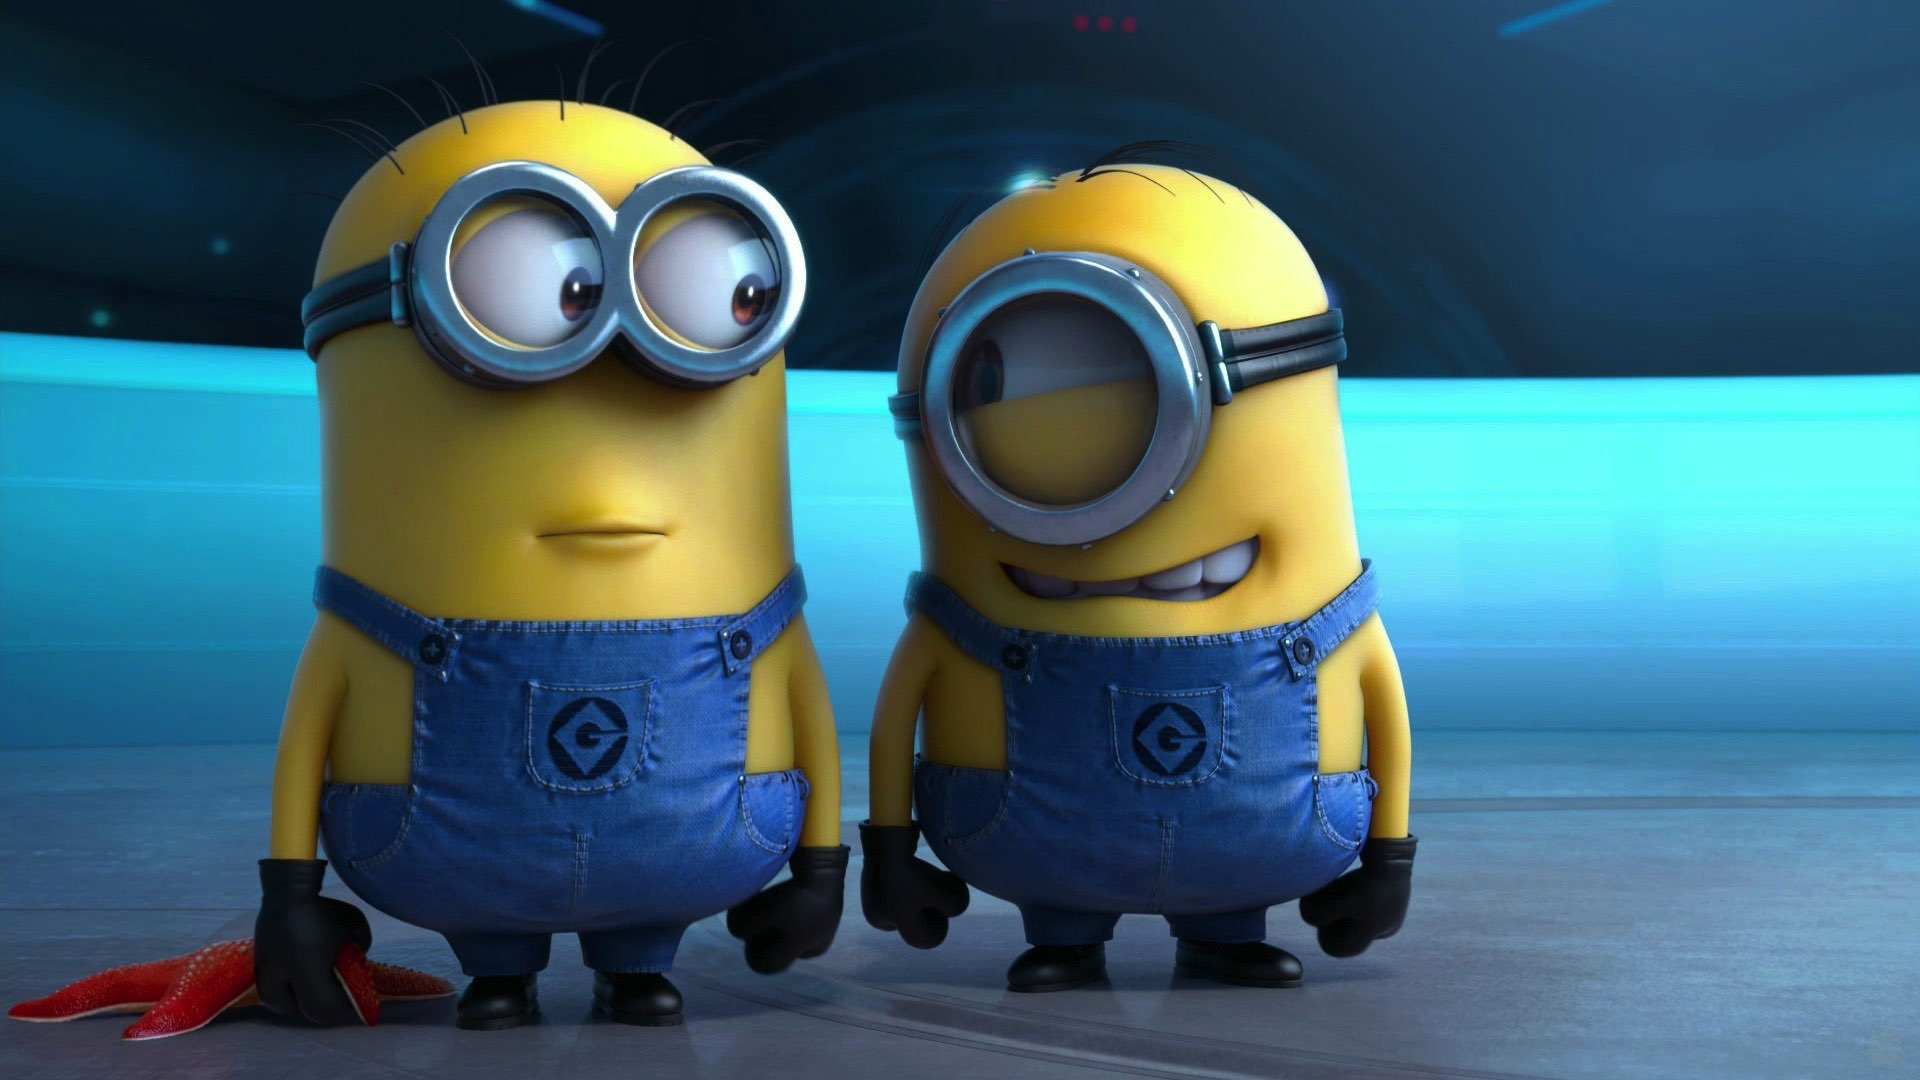

In [ ]:
cv2_imshow(raw_img)

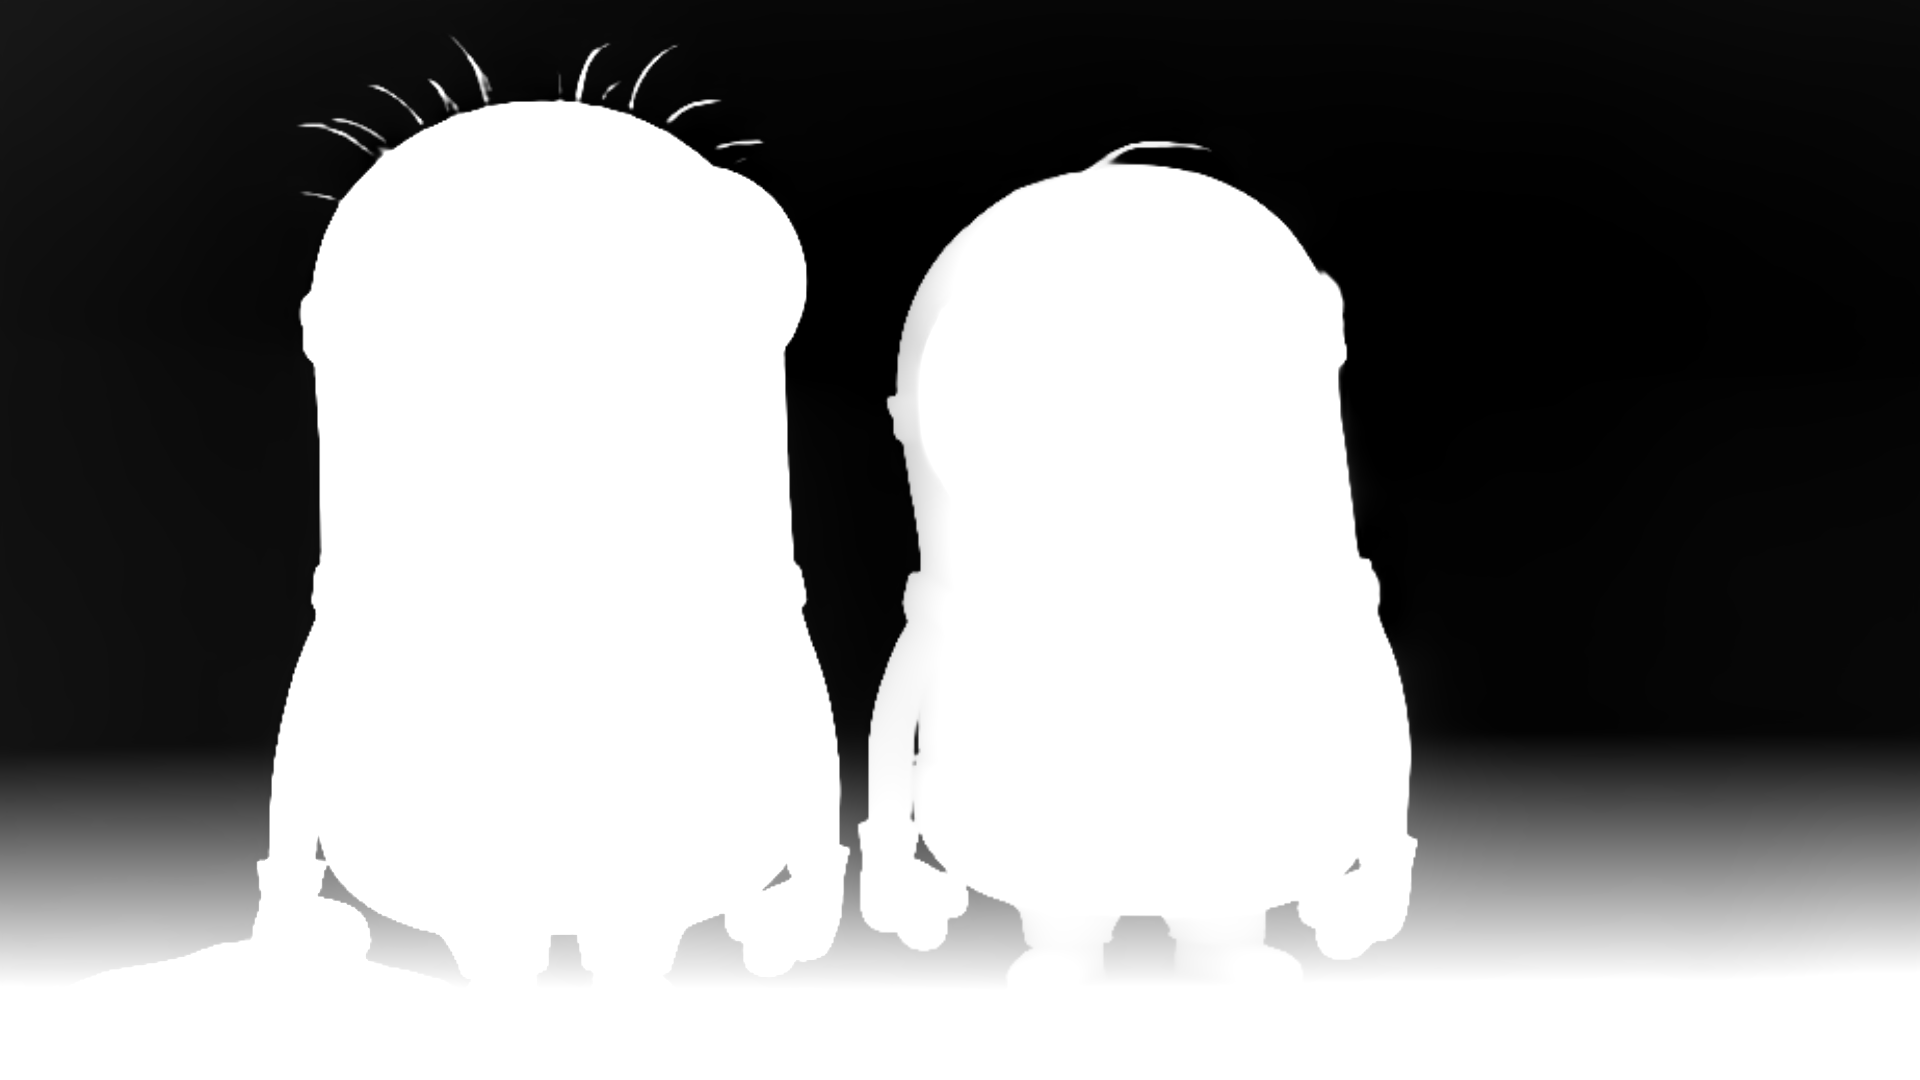

In [ ]:
cv2_imshow(depth)

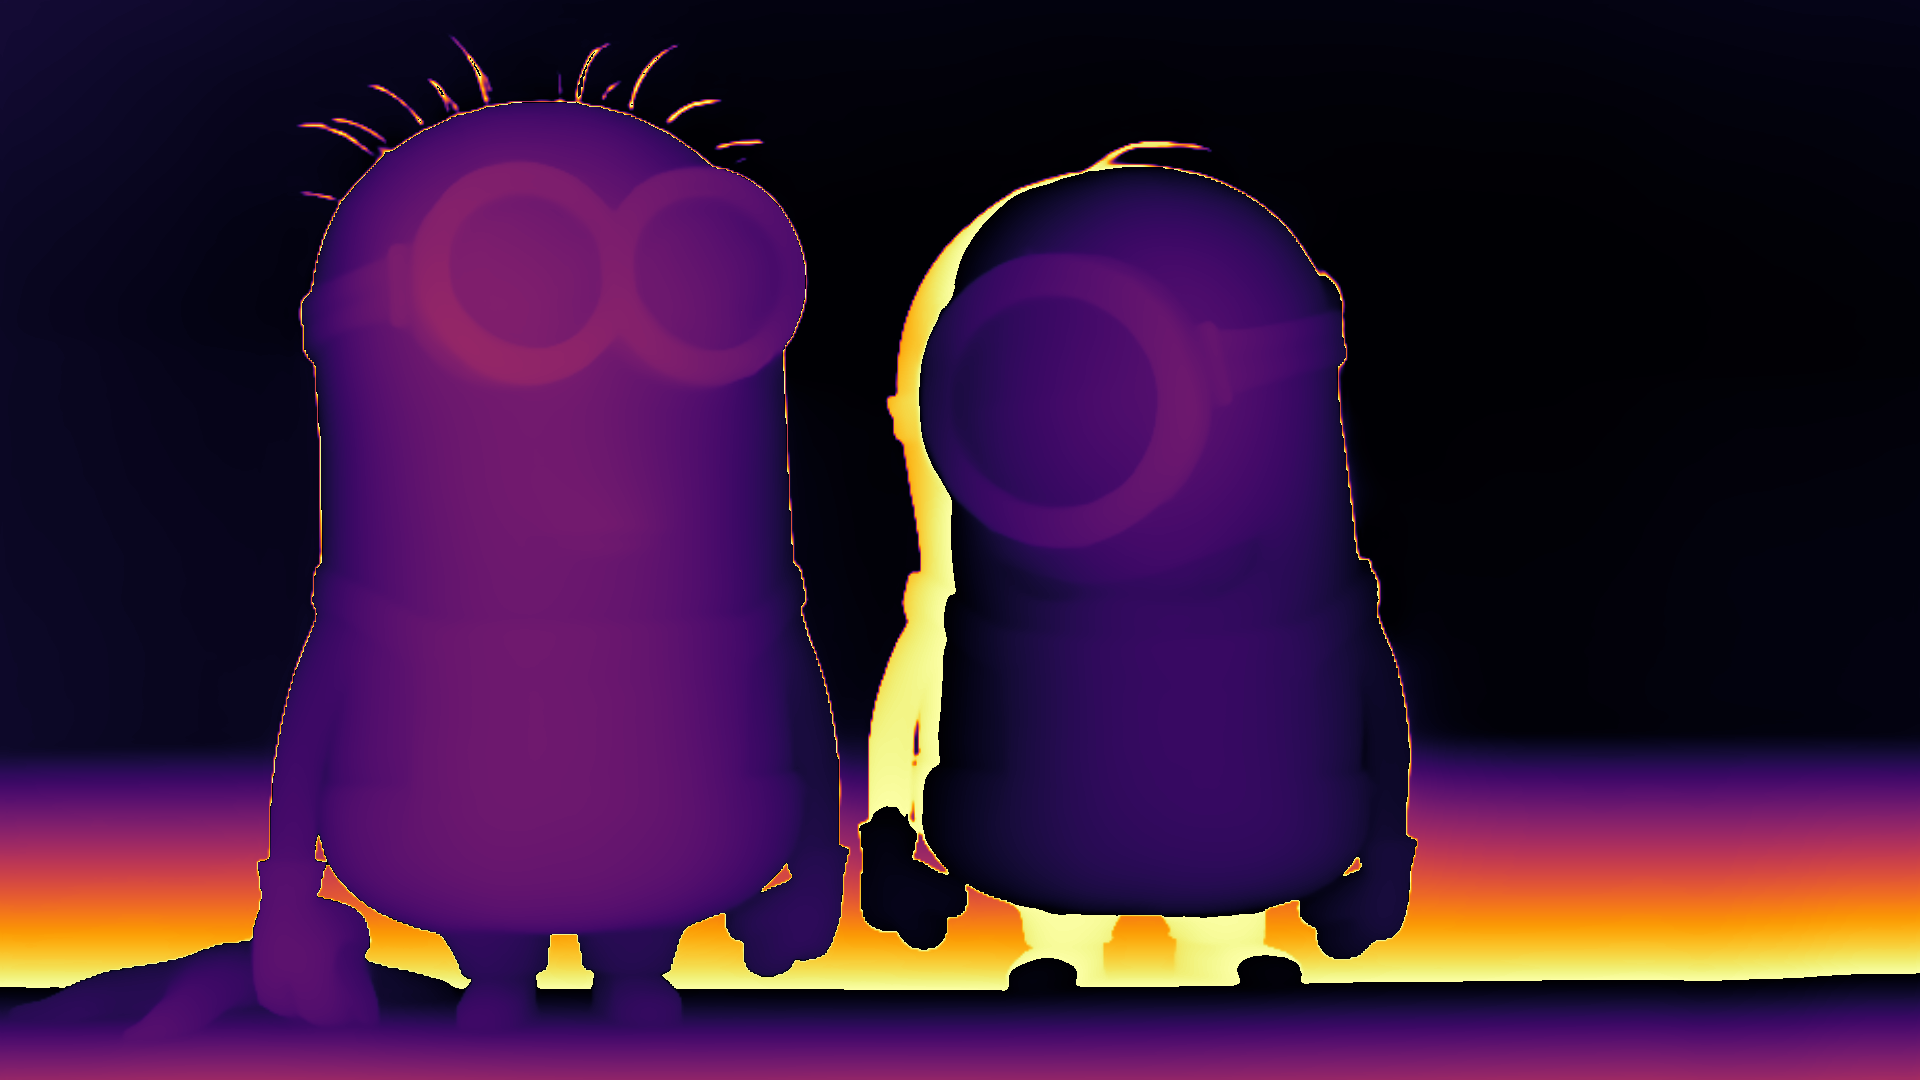

In [ ]:
depth_uint8 = depth.astype(np.uint8)
depth_color = cv2.applyColorMap(depth_uint8, cv2.COLORMAP_INFERNO)
cv2_imshow(depth_color)

Point cloud saved to /content/drive/My Drive/Depth_Estimation/point_cloud.ply


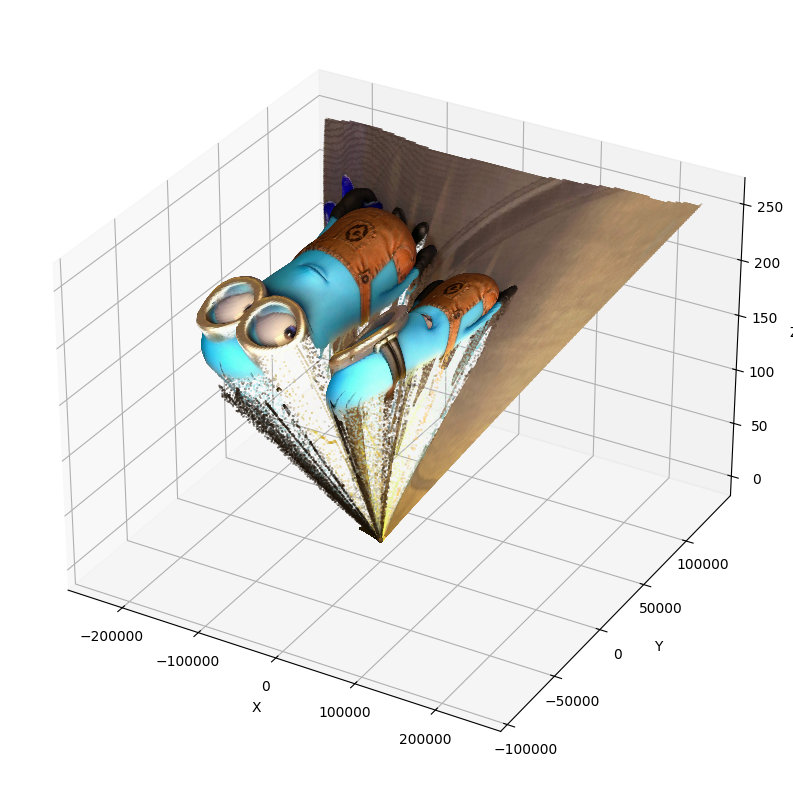

In [ ]:
import os
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def depth_to_point_cloud(depth, rgb_image=None, focal_length=1.0, scale=1.0):
    """
    Converts a depth map to a 3D point cloud.

    Args:
        depth (np.ndarray): Depth map (H x W).
        rgb_image (np.ndarray): Optional RGB image for coloring (H x W x 3).
        focal_length (float): Focal length of the camera.
        scale (float): Scaling factor for the depth values.

    Returns:
        points (np.ndarray): Nx3 array of 3D points.
        colors (np.ndarray): Nx3 array of RGB colors (optional).
    """
    h, w = depth.shape
    i, j = np.meshgrid(np.arange(w), np.arange(h))
    z = depth / scale  # Scale the depth values

    # Convert depth to 3D points (x, y, z)
    x = (i - w / 2) * z / focal_length
    y = (j - h / 2) * z / focal_length
    points = np.stack((x, y, z), axis=-1).reshape(-1, 3)

    # Optional: Associate colors with the points
    colors = None
    if rgb_image is not None:
        colors = rgb_image.reshape(-1, 3) / 255.0  # Normalize RGB values to [0, 1]

    return points, colors

# Generate 3D point cloud
depth_normalized = cv2.normalize(depth, None, 0, 255, cv2.NORM_MINMAX)
depth_uint8 = depth_normalized.astype(np.uint8)

points, colors = depth_to_point_cloud(depth_uint8, raw_img)

# Save point cloud to a .PLY file
def save_point_cloud_ply(filename, points, colors=None):
    with open(filename, 'w') as f:
        # Write header
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(points)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        if colors is not None:
            f.write("property uchar red\n")
            f.write("property uchar green\n")
            f.write("property uchar blue\n")
        f.write("end_header\n")

        # Write points and colors
        for i in range(len(points)):
            line = f"{points[i, 0]} {points[i, 1]} {points[i, 2]}"
            if colors is not None:
                color = (colors[i] * 255).astype(int)
                line += f" {color[0]} {color[1]} {color[2]}"
            f.write(line + "\n")

output_ply_file = '/content/drive/My Drive/Depth_Estimation/point_cloud.ply'
save_point_cloud_ply(output_ply_file, points, colors)
print(f"Point cloud saved to {output_ply_file}")

# Visualize 3D point cloud (Optional)
def visualize_point_cloud(points, colors=None):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    if colors is not None:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=0.1)
    else:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=0.1, c='b')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

visualize_point_cloud(points, colors)


In [ ]:
!pip install open3d

import open3d as o3d
import numpy as np

def create_3d_mesh(points, colors=None):
    """
    Create and visualize a 3D mesh from a point cloud.

    Args:
        points (np.ndarray): Nx3 array of 3D points.
        colors (np.ndarray): Optional Nx3 array of RGB colors.
    """
    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)

    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)

    # Estimate normals
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

    # Generate a mesh using Ball-Pivoting algorithm
    distances = pcd.compute_nearest_neighbor_distance()
    avg_dist = np.mean(distances)
    radius = avg_dist * 2  # Adjust the radius as needed
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
        pcd, o3d.utility.DoubleVector([radius, radius * 2])
    )

    # Visualize the mesh
    o3d.visualization.draw_geometries([mesh])

# Generate and visualize the 3D mesh
create_3d_mesh(points, colors)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.7/399.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Unins